## MIPEM: Media Ingredient Prediction for Environmental Microorganisms

In [1]:
import pandas as pd
import os

### User input: <br>
<u> **Insert your data here, and run the notebook.** </u> <br>
* A PDF report will be generated in your current working directory (**DATA_DIR**). <br>
* **TEST_FILE** should be your organism's .csv file, with two columns: ["filename", "ec"]. These can be extracted from a .gff file in the 01-Data.ipynb notebook ("MAG Processing" section), or prepared independently.

In [2]:
DATA_DIR = "~/Desktop/Projects/media-prediction/" # Replace with the path to this repository 
TEST_FILE = pd.read_csv(os.path.join(DATA_DIR, "data", "test.csv")) # Replace "test.csv" with your file

# [OPTIONAL] If your file contains multiple organisms ("filename" column), you can adjust this filter to extract your organism of interest #
OOI = "Bin.003.fastaCG_F" 

### Initialization

Note: some notebooks were generated outside of this workflow by merging outputs from 01-Data.ipynb (e.g., UMAP_input.csv, test.csv, and ec-cofactor.csv)

In [3]:
# Setting random environment
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
RANDOM_SEED = 26

# For collecting report figures
from matplotlib.backends.backend_pdf import PdfPages
facet_figs = []

# Upload training dataset (derived from 01-Data.ipynb)
df = pd.read_csv(os.path.join(DATA_DIR, "data", "UMAP_input.csv"), low_memory=False)

#### Load Cache

In [4]:
import joblib
import numpy as np
import pickle

CACHE_DIR = "model_cache"

# Load cached files (derived from 02-Model_Cache.ipynb)
umap_model = joblib.load(f"{CACHE_DIR}/umap_model.joblib")
umap_embedding = np.load(f"{CACHE_DIR}/umap_embedding.npy")
nn_model = joblib.load(f"{CACHE_DIR}/nn_model.joblib")
lof_model = joblib.load(f"{CACHE_DIR}/lof_model.joblib")
train_knn_mean_dist = np.load(f"{CACHE_DIR}/train_knn_mean_dist.npy")
train_lof_scores = np.load(f"{CACHE_DIR}/train_lof_scores.npy")
cluster_labels = np.load(f"{CACHE_DIR}/cluster_labels.npy")

with open(f"{CACHE_DIR}/train_metadata.pkl", "rb") as f:
    meta = pickle.load(f)

#### Format input

In [5]:
# Upload test case (.csv with columns ["filename", "ec"])
test_df = TEST_FILE.copy()

# Select a single test sample if file contains multiple
bin = test_df[test_df["filename"].str.contains(OOI, na=False)]

# Format for UMAP
bin = bin[["filename", "ec"]].value_counts().reset_index()
test = bin.pivot(index=["filename"], columns="ec", values="count").fillna(0.0)

In [6]:
# Resize test case to include all of the same EC numbers as the training dataset
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

train = df.copy()
train = train.drop(["taxon_id", "media_id"], axis=1)

for col in train.columns:
    if col not in test.columns:
        test[col] = 0

test = test[train.columns]

### UMAP visualization
UMAP is an unsupervised approach used to reduce dimensionality and map the test organism to the metabolic space of the training dataset. Use this in combination with the K-Nearest Neighbors to visualize how closely your organism fits with the training dataset to inform media predictions.

In [7]:
# Embed test sample with UMAP
test_embedding = umap_model.transform(test)

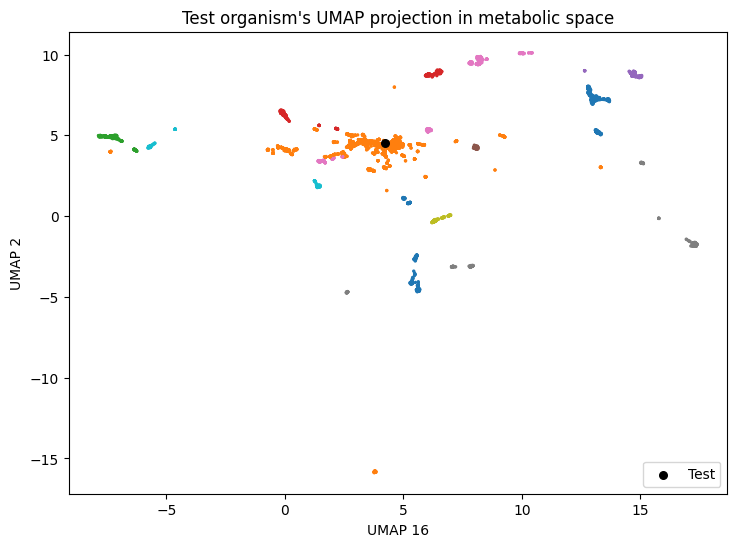

In [8]:
# UMAP projection
import matplotlib.pyplot as plt

plt.figure(figsize=(8.5, 6))

# Reference organisms from constructed dataset
plt.scatter(umap_embedding[:, 15], umap_embedding[:, 1], c=cluster_labels, cmap="tab10", s=2)
# Components 16 and 2 determined highest importance via XGBoost/Shap (02-Model_Cache.ipynb)

# Test sample
plt.scatter(test_embedding[0, 0], test_embedding[0, 1], c="black", s=30, label="Test")

plt.xlabel("UMAP 16")
plt.ylabel("UMAP 2")
plt.title("Test organism's UMAP projection in metabolic space")
plt.legend(loc="lower right")

#plt.show() # hide if saving to .pdf
facet_figs.append(plt.gcf()) 

### Nearest neighbors

In [9]:
# Nearest neighbor model
distances, indices = nn_model.kneighbors(test)
test_mean_dist = distances[:, 1:].mean()

# Global distance
knn_percentile = (train_knn_mean_dist < test_mean_dist).mean() * 100

# Local outlier factor
lof_score = -lof_model.score_samples(test)[0]
lof_percentile = (train_lof_scores < lof_score).mean() * 100

print(f"kNN percentile: {knn_percentile:.1f}%")
print(f"LOF percentile: {lof_percentile:.1f}%")

c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\metrics\pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\jakel\anaconda3\envs\media\Lib\site-packages\sklearn\metrics\pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


kNN percentile: 97.3%
LOF percentile: 73.1%


In [10]:
# Show nearest neighbors and Jaccard distances
neighbor_indices = np.array(indices, dtype=int).flatten()
neighbor_distances = distances.flatten()
neighbors = df.iloc[neighbor_indices][['taxon_id', 'media_id']].copy()
neighbors['jaccard_distance'] = neighbor_distances

print("Nearest neighbors:")
display(neighbors)

Nearest neighbors:


,taxon_id,media_id,jaccard_distance
6419,47834.0,1076b,0.803419
362,1136073.0,1076b,0.814159
6420,47835.0,1076b,0.817460
5422,358687.0,J346,0.840764
5357,351343.0,J346,0.840764
6045,424799.0,J346,0.840764
646,126734.0,1012a,0.841530
1797,1597.0,J84,0.845588
7347,650366.0,J13,0.845588
1400,1490.0,J84,0.845588


#### Nearest neighbor media

In [11]:
neighbors_df = pd.DataFrame(neighbors)
neighbors_df = neighbors_df.drop(columns=["jaccard_distance"])

# Show the media of the nearest neighboring taxa based on their metabolic characteristics
media_df = pd.read_csv(os.path.join(DATA_DIR, "data", "mediadive", "mediadive-complete.csv"), low_memory=False) #"mediadive-complete-explo.csv"
prediction = pd.merge(left=neighbors_df, right=media_df, on="media_id", how="left")
prediction = prediction.drop(["taxon_id"], axis=1)

# Occurrence column shows how many of the neighbors utilize each media type
prediction["occurrence"] = prediction["media_id"].map(prediction["media_id"].value_counts(normalize=True))
prediction = prediction.drop_duplicates()

# Sort by occurrence
df_sorted = prediction.sort_values(by="occurrence", ascending=False)

df_sorted.head()

,media_id,solutions,solution_names,components,component_ids,component_gL,steps,sub_solutions,solution_ids,solution_ml,occurrence
7,J84,[3711],['Main sol. J84'],"['GAM broth', 'Agar', 'Distilled water']","[1620, 3, 4]","[59, 2, None]",[None],[],[],[],0.3125
8,J13,"[3632, 3633, 3634]","['Main sol. J13', 'Solution A', 'Solution B']","['Lab-Lemco beef extract', 'Proteose peptone n...","[599, 316, 124, 125, 16, 1600, 5, 199, 22, 3, ...","[2.85714, 9.52381, 4.7619, 2.85714, 4.7619, No...","[[{'step': 'Adjust pH to 7.2.'}, {'step': 'To ...","['Solution A', 'Solution B']","[3633, 3634]","[10, 5]",0.2500
0,1076b,[2173],['Main sol. 1076b'],"['PPLO broth', 'Tryptone', 'Bacto peptone', 'D...","[953, 71, 19, 4, 958, 1680, 16, 954, 960, 5, 3...","[3.5, 10, 5, None, 0.2, None, 0.4, None, None,...",[[{'step': 'The difference between this medium...,[],[],[],0.1875
3,J346,[4066],['Main sol. J346'],"['Yeast extract', 'Proteose peptone no. 3', 'C...","[16, 316, 101, 5, 199, 438, 10, 8, 3, 4]","[0.5, 0.5, 0.5, 0.5, 0.5, 0.3, 0.3, 0.05, 15, ...","[[{'step': 'Adjust pH to 7.2.'}, {'step': 'Com...",[],[],[],0.1875
6,1012a,[6336],['Main sol. 1012a'],"['Nutrient broth', 'Casamino acids', 'Yeast ex...","[269, 101, 16, 3, 79, 7, 4]","[0.8, 0.5, 0.1, 12, 0.6, 0.3, None]",[[{'step': 'Preparation of double-layered agar...,[],[],[],0.0625


#### Cofactor comparison

In [12]:
# Load training set EC and cofactor info
training_cofactors = pd.read_csv(os.path.join(DATA_DIR, "data", "ec-cofactor.csv"))

# Filter for the nearest neighbors (rather than entire training dataset)
neighbors_list = neighbors["taxon_id"].to_list()
filt = training_cofactors["taxon_id"].isin(neighbors_list)
train_co = training_cofactors[filt]

train_co.head()

,media_id,taxon_id,source,ec,CofactorFinal
100676,1012a,126734.0,uniprot,3.6.1.66,Mg
100677,1012a,126734.0,uniprot,2.1.1.192,Fe
100678,1012a,126734.0,uniprot,2.7.4.3,Mg
100679,1012a,126734.0,uniprot,3.1.26.3,Mg
100680,1012a,126734.0,uniprot,4.2.1.113,metal


In [13]:
# Align test case cofactor info based on EC numbers
test_co = bin[["filename", "ec"]]
tr_co = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "cofactors-taxa.csv"), low_memory=False)
tr_co = tr_co[["Query EC", "CofactorFinal"]]
tr_co = tr_co.rename(columns={"Query EC":"ec"})
merge_co = pd.merge(left=test_co, right=tr_co, on="ec", how="left")

# Focus on metals / trace elements
metals = pd.read_csv(os.path.join(DATA_DIR, "data", "cofactors", "metals-list.csv"))
metals_list = metals["Metals"].to_list()
filter = merge_co["CofactorFinal"].isin(metals_list)
test_co = merge_co[filter]

test_co.head()

,filename,ec,CofactorFinal
0,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Fe
2,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Mg
3,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,metal
4,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Zn
5,KBase_derived_Bin.003.fastaCG_F_extracted_bins...,3.6.4.12,Mn


In [14]:
# Dictionary for undefined metals
dictionary = {"a monovalent": "UM", "metal": "UM"}

# Calculating relative abundances of cofactors between training vs. test case
def summarize_cofactors(df, label):
    return (
        df.assign(
            CofactorFinal=df["CofactorFinal"].replace(dictionary, regex=True)
        )
        .value_counts("CofactorFinal", normalize=True)
        .rename("ra")
        .reset_index()
        .assign(
            ct=lambda x: (x["ra"] * len(df)).round().astype(int),
            Set=label
        )
        [["CofactorFinal", "ct", "ra", "Set"]]
    )

# Storing dataframe for our relative abundances
counts = pd.concat([summarize_cofactors(train_co, "Training"), summarize_cofactors(test_co, "Test")], ignore_index=True)
counts = counts.sort_values("ct", ascending=False)

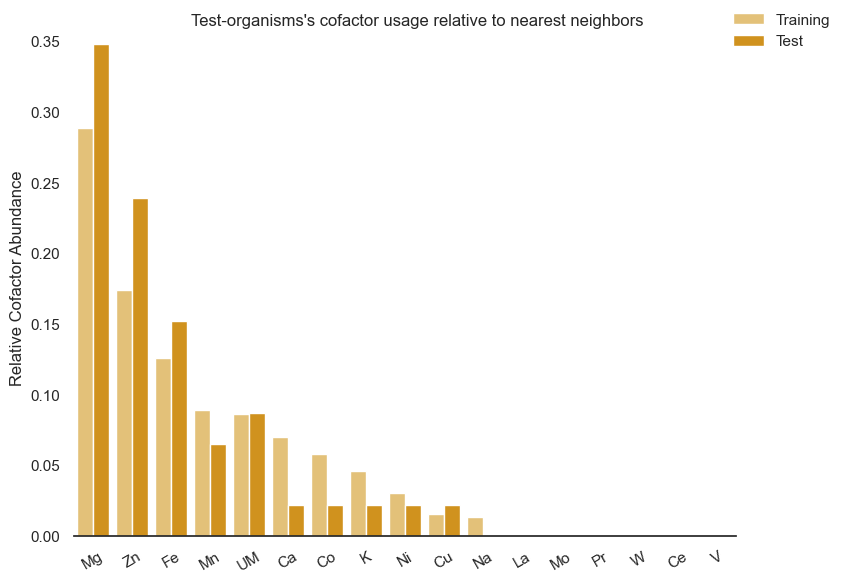

In [15]:
import seaborn as sns
sns.set_theme(style="white")

colors = ["#f5c767", "#ee9b00"]

g = sns.catplot(
    data=counts, kind="bar",
    x="CofactorFinal", y="ra", hue="Set", 
    palette=colors, alpha=1, height=6, aspect=8.5/6
)

g.despine(left=True)
g.set_axis_labels("", "Relative Cofactor Abundance")
g.tick_params(axis='x', rotation=30)
g.fig.suptitle("Test-organisms's cofactor usage relative to nearest neighbors", y=0.98, fontsize=12)
g.legend.set_loc("upper right")
g.legend.set_title("")
g.fig.set_size_inches(8.5, 6)

### Generate report

In [16]:
import sys
sys.path.append("..")
import modules.media_report as report

facet_figs.extend(
    report.generate_facet_figs(
        neighbors=neighbors,
        knn_percentile=knn_percentile,
        lof_percentile=lof_percentile,
        df_sorted=df_sorted,
        prediction=prediction
    )
)

facet_figs.append(g.fig)

with PdfPages("report.pdf") as pdf:
    for fig_item in facet_figs:
        pdf.savefig(fig_item) 
        plt.close(fig_item)  